In [1]:
# file=open('SMSSpamCollection','r')
# text=(file.read())
# text=text.split('\t')
# text

In [2]:
from colorsys import yiq_to_rgb

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pydantic.experimental.pipeline import transform

In [3]:
df=pd.read_csv('SMSSpamCollection',sep='\t',names=['label','text'])

In [4]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<Axes: xlabel='count', ylabel='label'>

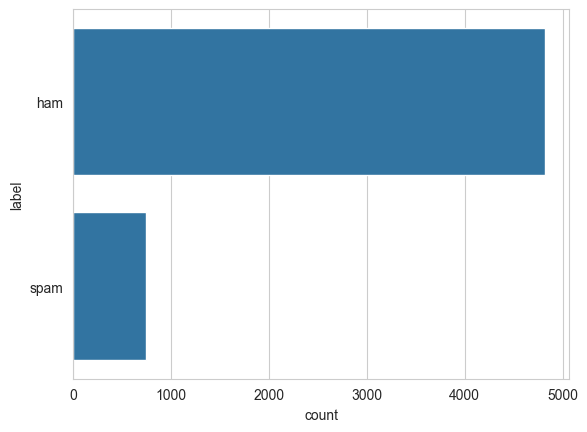

In [5]:
sns.countplot(df['label'])

In [6]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x29442162a50>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.59%'),
  Text(0.5475662588910611, -0.24529816983428027, '13.41%')])

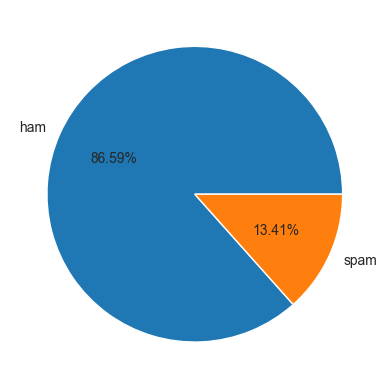

In [7]:
plt.pie(df['label'].value_counts(),labels=df['label'].value_counts().index,autopct='%2.2f%%')

In [8]:
#Input variable
x=df['text']
#output variable
y=df['label']

In [9]:
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import stopwords

In [10]:
swords=stopwords.words('english')
ps=PorterStemmer()
wnl=WordNetLemmatizer()

In [11]:
def clean_text(sent):
    tokens1=word_tokenize(sent)
    tokens2=[token for token in tokens1 if token.isalpha()]
    tokens3=[ps.stem(token.lower()) for token in tokens2 if token.lower() not in swords]
    tags=pos_tag(tokens3)
    #  tokens4=[]
    # for word in tags:
    #     if word[1].startswith('N'):
    #         tokens4.append(wnl.lemmatize(word[0],pos='n'))
    #     elif word[1].startswith('V'):
    #         tokens4.append(wnl.lemmatize(word[0],pos='v'))
    #     elif word[1].startswith('J'):
    #         tokens4.append(wnl.lemmatize(word[0],pos='a'))
    #     else:
    #         tokens4.append(word[0])
    '''Lemmatization is more useful, but using stemming for recreating results shown in class'''

    return tokens3

In [12]:
sent='Hello friends! How are you? Welcome to Python Programming.'
print(clean_text(sent))

['hello', 'friend', 'welcom', 'python', 'program']


In [13]:
pos_tag(word_tokenize(sent))

[('Hello', 'NNP'),
 ('friends', 'VBZ'),
 ('!', '.'),
 ('How', 'WRB'),
 ('are', 'VBP'),
 ('you', 'PRP'),
 ('?', '.'),
 ('Welcome', 'VB'),
 ('to', 'TO'),
 ('Python', 'NNP'),
 ('Programming', 'NNP'),
 ('.', '.')]

In [14]:
wnl.lemmatize('programming',pos='v')

'program'

In [15]:
#!pip install wordcloud

In [16]:
ham=df['text'].loc[df['label']=='ham']
spam=df['text'].loc[df['label']=='spam']

In [17]:
spam.shape

(747,)

In [18]:
ham_messages=ham.sum()
spam_messages=spam.sum()

In [19]:
spam_messages

'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'sFreeMsg Hey there darling it\'s been 3 week\'s now and no word back! I\'d like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcvWINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 infoURGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or clic

In [20]:
len(spam_messages)

103587

In [21]:
len(ham_messages)

344903

In [22]:
from wordcloud import WordCloud

In [23]:
wc_spam=WordCloud(background_color='white',max_words=50,random_state=24).generate(spam_messages)

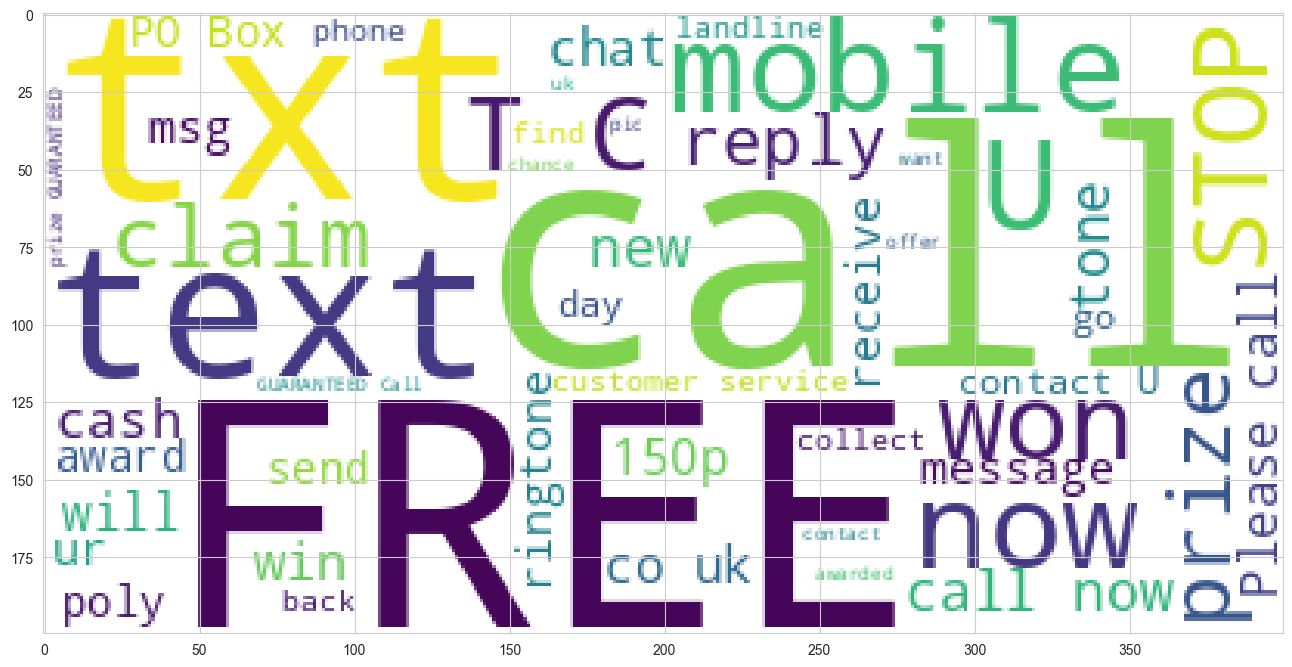

In [24]:
plt.figure(figsize=(16,9))
plt.imshow(wc_spam)

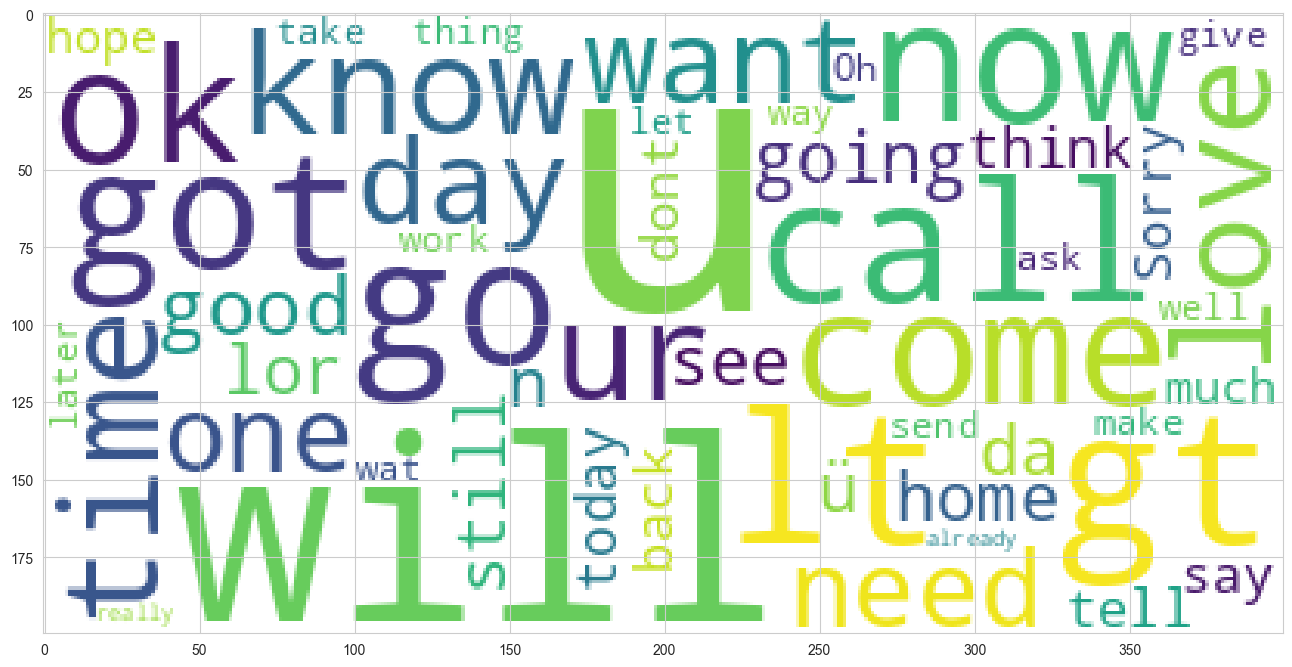

In [25]:
wc_ham = WordCloud(background_color='white', max_words=50, random_state=24).generate(ham_messages)
plt.figure(figsize=(16, 9))
plt.imshow(wc_ham)

In [26]:
x.apply(clean_text)

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, wkli, comp, win, fa, cup, final,...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [time, tri, contact, u, pound, prize, claim, e...
5568                       [ü, b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5572, dtype: object

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
tfidf=TfidfVectorizer(analyzer=clean_text)

In [29]:
x_vect=tfidf.fit_transform(x)

In [30]:
x_vect.shape

(5572, 5925)

In [31]:
#cross validation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x_vect,y,random_state=0)

In [33]:
x_train.shape

(4179, 5925)

In [34]:
x_test.shape

(1393, 5925)

In [35]:
#Build model
from sklearn.svm import SVC

In [36]:
svm=SVC(kernel='linear')

In [37]:
svm.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
y_pred=svm.predict(x_test)

In [39]:
print(accuracy_score(y_test,y_pred))

0.9827709978463748


In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.88      0.93       185

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [41]:
svm = SVC(kernel='rbf')
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9813352476669059
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       1.00      0.86      0.92       185

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [42]:
svm = SVC(kernel='poly')
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.949748743718593
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1208
        spam       1.00      0.62      0.77       185

    accuracy                           0.95      1393
   macro avg       0.97      0.81      0.87      1393
weighted avg       0.95      0.95      0.94      1393



In [43]:
svm = SVC(kernel='sigmoid')
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9798994974874372
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.98      0.87      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



In [44]:
#Trying on another data
test=open('sample.csv','r')
test=test.readlines()

In [45]:
test

['Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.,,\n',
 'As a valued customer, I am pleased to advise you that following recent review of your Mob No. you are awarded with a Â£1500 Bonus Prize, call 09066364589\n',
 '"Today is ""song dedicated day.."" Which song will u dedicate for me? Send this to all ur valuable frnds but first rply me...",,\n']

In [46]:
svm = SVC(kernel='linear')
svm.fit(x_train, y_train)
y_pred = svm.predict(tfidf.transform(test))

In [47]:
y_pred

array(['ham', 'spam', 'ham'], dtype=object)

### 4/12/2025

In [50]:
import joblib

In [52]:
joblib.dump(svm,'classifier.model')
joblib.dump(tfidf,'preprocessor.model')

['preprocessor.model']

In [54]:
joblib.dump(clean_text,'classifier.model')

['classifier.model']